# Preparación vectorial y ponderación AHP del Índice de Potencial de Aguas Subterráneas (GWPI)

**Sistema Acuífero Raigón — piloto Ciudad del Plata–Libertad, San José, Uruguay**

Juan Nahuel Lamas · Grupo de Investigaciones Espaciales (GIEx), UTEC
Licenciado en Ciencias Geológicas (FCEN-UBA) · Maestrando en Geociencias (UdelaR–PEDECIBA)

---

## Qué hace este notebook

En el flujo publicado en esta carpeta, la integración multicriterio del GWPI se resolvió en **ArcGIS Pro con
ModelBuilder** (ver `resultados/01_modelbuilder_flujo-GPWI.png`) y los scripts de `scripts/` reproducen la parte
ráster: cálculo de pesos por autovector y suma ponderada.

Este notebook cubre **la etapa vectorial previa**, que en el proyecto original se ejecutó de forma interactiva
dentro del SIG y por lo tanto no quedaba documentada de manera reproducible. Reescribirla en Python tiene un
propósito concreto: que cualquiera pueda auditar y volver a correr las decisiones que definen los ratings de
entrada, que es donde realmente se juega el resultado de un análisis multicriterio.

Las dos funciones que se solapan con `../scripts/` (pesos AHP y reclasificación de Jenks) se
reimplementan acá sólo para que el notebook corra sin dependencias de rutas relativas; la
implementación de referencia del proyecto sigue siendo la de `scripts/`.

Se resuelven aquí:

| Paso | Operación | Herramienta |
|---|---|---|
| 1 | Manejo de sistemas de referencia (SIRGAS-ROU98 geográfico → UTM 21S) | `pyproj`, `geopandas` |
| 2 | Construcción de la malla de análisis de 1 km | `shapely`, `geopandas` |
| 3 | Densidad de drenaje por celda | `geopandas.overlay` |
| 4 | Distancia a cursos de agua | `geopandas.sjoin_nearest` |
| 5 | Unidad geológica dominante por celda (ponderada por área) | `geopandas.overlay` + `groupby` |
| 6 | Estadística zonal de pendiente y TWI | `rasterio.features.rasterize` + `numpy.bincount` |
| 7 | Reclasificación 1–5 por cortes naturales de Jenks | `mapclassify` |
| 8 | Pesos AHP por autovector y razón de consistencia | `numpy` |
| 9 | Integración del GWPI y exportación a GeoPackage y GeoTIFF | `geopandas`, `rasterio` |
| 10 | Validación contra caudales específicos de pozos | `scipy.stats` |

## Sobre los datos

> **Nota importante.** Este notebook **no distribuye las capas originales del proyecto**: la geología
> 1:100.000, la red de drenaje de DINAGUA y los datos de pozos están sujetos a las condiciones de uso de
> las instituciones que los proveyeron, y el informe del proyecto está en proceso de publicación.
>
> Para que el notebook sea **ejecutable por cualquiera**, si no encuentra las capas reales en `datos/`
> genera un conjunto sintético reproducible (semilla fija) sobre la envolvente aproximada del área piloto,
> con la misma estructura de atributos y las mismas unidades geológicas y ratings del caso real. **Los números que produce
> esta corrida son, por lo tanto, demostrativos: sirven para auditar el código, no para citar resultados.**
> Los resultados publicados del proyecto provienen de las capas reales y están en `resultados/`.
>
> Si se colocan los archivos reales en `datos/` con los nombres indicados en la celda de carga, el notebook
> los usa sin ningún otro cambio.

## 0. Entorno

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shapely
from rasterio.features import rasterize
from rasterio.transform import from_origin
from scipy import stats
from shapely.geometry import LineString, Point, box
from shapely.ops import voronoi_diagram

warnings.filterwarnings("ignore", category=RuntimeWarning)

print(f"geopandas   {gpd.__version__}")
print(f"shapely     {shapely.__version__}")
print(f"rasterio    {rasterio.__version__}")
print(f"mapclassify {mapclassify.__version__}")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")

geopandas   1.1.4
shapely     2.1.2
rasterio    1.4.4
mapclassify 2.10.0
pandas      3.0.2
numpy       2.4.4


In [2]:
# ── Configuración del proyecto ────────────────────────────────────────────────
CRS_GEO = "EPSG:5381"   # SIRGAS-ROU98 (geográficas 2D) — CRS oficial del Uruguay
CRS_PRJ = "EPSG:5382"   # SIRGAS-ROU98 / UTM zona 21S   — CRS métrico de trabajo

CELDA_M = 1000          # lado de la celda de análisis, en metros
RES_M   = 30            # resolución de los rásteres continuos, en metros
SEMILLA = 20250903      # semilla para la generación sintética reproducible

DIR_DATOS  = Path("datos")
DIR_SALIDA = Path("salidas")
DIR_SALIDA.mkdir(exist_ok=True)

rng = np.random.default_rng(SEMILLA)

# Envolvente aproximada del área piloto Ciudad del Plata–Libertad (San José), en grados.
# El piloto real cubre unos 700 km² sobre el Sistema Acuífero Raigón.
BBOX_GEO = (-56.92, -34.78, -56.58, -34.56)  # (oeste, sur, este, norte)

## 1. Sistemas de referencia

Uruguay adoptó **SIRGAS-ROU98** como marco geodésico oficial. En el territorio conviven dos husos UTM
(21S al oeste del meridiano 54°O y 22S al este), y el acuífero Raigón cae íntegramente en el **huso 21S**.

Toda operación métrica —longitudes, áreas, distancias, buffers— se hace en el CRS proyectado. Es un error
frecuente y silencioso calcular distancias sobre coordenadas geográficas: no falla, simplemente devuelve
grados decimales interpretados como metros. La celda siguiente cuantifica ese error para dejarlo explícito.

In [3]:
from pyproj import CRS

for codigo in ("EPSG:5381", "EPSG:5382", "EPSG:5383"):
    crs = CRS.from_user_input(codigo)
    print(f"{codigo}  {crs.name:35s}  unidades: {crs.axis_info[0].unit_name}")

EPSG:5381  SIRGAS-ROU98                         unidades: degree
EPSG:5382  SIRGAS-ROU98 / UTM zone 21S          unidades: metre
EPSG:5383  SIRGAS-ROU98 / UTM zone 22S          unidades: metre


In [4]:
# Área de estudio como GeoDataFrame, y demostración del efecto del CRS
aoi_geo = gpd.GeoDataFrame(
    {"nombre": ["Piloto Ciudad del Plata–Libertad (envolvente aproximada)"]},
    geometry=[box(*BBOX_GEO)],
    crs=CRS_GEO,
)
aoi = aoi_geo.to_crs(CRS_PRJ)

area_mal = aoi_geo.geometry.area.iloc[0]                 # grados² — sin sentido físico
area_bien = aoi.geometry.area.iloc[0] / 1e6              # km²

print(f"Área calculada en {CRS_GEO} : {area_mal:>12.4f}  (grados cuadrados — no interpretable)")
print(f"Área calculada en {CRS_PRJ} : {area_bien:>12.1f}  km²")
print(f"\nExtensión proyectada (m): {[round(v) for v in aoi.total_bounds]}")

Área calculada en EPSG:5381 :       0.0748  (grados cuadrados — no interpretable)
Área calculada en EPSG:5382 :        759.9  km²

Extensión proyectada (m): [507320, 6151273, 538530, 6175747]


/tmp/ipykernel_1700/1119290939.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_mal = aoi_geo.geometry.area.iloc[0]                 # grados² — sin sentido físico


## 2. Capas de entrada

La función `cargar_o_simular` busca primero los archivos reales. Si no están, construye un conjunto
sintético con la misma estructura de atributos. **Las unidades geológicas y sus ratings son los reales del
proyecto**, tomados de la sección "Rating de Geología" del [README de la carpeta](../README.md): derivan de
los sub-índices DRASTIC de "Tipo de Acuífero" e "Impacto de la Zona Vadosa" de Bessouat et al., no del
índice de vulnerabilidad agregado, porque miden conductividad hidráulica y porosidad litológica y no
vulnerabilidad a la contaminación.

In [5]:
# Calificación hidrogeológica de las unidades (1 = pobre, 5 = muy favorable).
# Criterio: conductividad hidráulica y comportamiento documentado de cada unidad.
# Fuente: ../README.md, sección "Rating de Geología". Los ratings derivan de los
# sub-índices DRASTIC "Tipo de Acuífero" e "Impacto de la Zona Vadosa" (Bessouat et al.),
# no del índice de vulnerabilidad agregado.
RATING_GEOLOGIA = {
    "Formación Camacho":       5,  # litología heterogénea; transición local a Raigón confinado
    "Formación Libertad":      5,  # limos esmectíticos; unidad confinante sobre la Fm. Raigón
    "Formación Raigón":        4,  # acuífero principal; arenas de alta transmisividad
    "Formación Chuy":          4,  # arenas medias a finas
    "Formación Dolores":       4,  # arcillas y limos con arena subordinada (Chuy confinado)
    "Duna":                    1,  # arena eólica no consolidada
    "Sedimentos actuales":     1,  # arenas costeras y cordones litorales recientes
    "Basamento precámbrico":   1,  # gneises y granitos; porosidad primaria nula
}
UNIDADES = list(RATING_GEOLOGIA)

# Proporciones aproximadas de cada unidad en el área piloto (sólo para la simulación)
PROP_UNIDADES = np.array([0.08, 0.20, 0.28, 0.10, 0.12, 0.06, 0.10, 0.06])


def _red_drenaje_sintetica(bounds, n_troncos=9, rng=rng):
    """Genera una red de drenaje dendrítica simple dentro de la envolvente dada."""
    x0, y0, x1, y1 = bounds
    lineas, ordenes = [], []
    for _ in range(n_troncos):
        n = rng.integers(6, 12)
        xs = np.sort(rng.uniform(x0, x1, n))
        ys = np.linspace(rng.uniform(y0, y1), rng.uniform(y0, y1), n)
        ys = ys + rng.normal(0, (y1 - y0) * 0.035, n)   # sinuosidad
        tronco = LineString(np.column_stack([xs, ys]))
        lineas.append(tronco); ordenes.append(int(rng.integers(3, 5)))
        for _ in range(rng.integers(2, 5)):             # afluentes
            t = rng.uniform(0.15, 0.85)
            p = tronco.interpolate(t, normalized=True)
            ang = rng.uniform(0, 2 * np.pi)
            largo = rng.uniform(0.06, 0.20) * (x1 - x0)
            q = Point(p.x + largo * np.cos(ang), p.y + largo * np.sin(ang))
            lineas.append(LineString([p, q])); ordenes.append(int(rng.integers(1, 3)))
    return gpd.GeoDataFrame({"orden": ordenes}, geometry=lineas, crs=CRS_PRJ)


def _geologia_sintetica(aoi_geom, n=34, rng=rng):
    """Teselado de Voronoi sobre semillas aleatorias, recortado al área de estudio."""
    x0, y0, x1, y1 = aoi_geom.bounds
    semillas = shapely.MultiPoint(
        [Point(rng.uniform(x0, x1), rng.uniform(y0, y1)) for _ in range(n)]
    )
    celdas = list(voronoi_diagram(semillas, envelope=aoi_geom).geoms)
    unidades = rng.choice(UNIDADES, size=len(celdas), p=PROP_UNIDADES)
    g = gpd.GeoDataFrame({"unidad": unidades}, geometry=celdas, crs=CRS_PRJ)
    g["geometry"] = g.geometry.intersection(aoi_geom)
    g = g[~g.geometry.is_empty & g.geometry.notna()].copy()
    return g.dissolve(by="unidad", as_index=False)


def _campo_suave(shape, escala, rng=rng):
    """Campo aleatorio espacialmente autocorrelacionado (suavizado gaussiano por FFT)."""
    ruido = rng.normal(size=shape)
    ky = np.fft.fftfreq(shape[0])[:, None]
    kx = np.fft.fftfreq(shape[1])[None, :]
    filtro = np.exp(-((kx**2 + ky**2) * escala**2))
    campo = np.real(np.fft.ifft2(np.fft.fft2(ruido) * filtro))
    return (campo - campo.min()) / (campo.max() - campo.min())

In [6]:
def cargar_o_simular():
    """Carga las capas reales si existen; si no, genera el conjunto sintético."""
    f_dren, f_geol, f_pozos = (DIR_DATOS / n for n in
                               ("drenaje.gpkg", "geologia.gpkg", "pozos.gpkg"))
    if f_dren.exists() and f_geol.exists():
        print(">> Usando las capas reales de datos/")
        dren = gpd.read_file(f_dren).to_crs(CRS_PRJ)
        geol = gpd.read_file(f_geol).to_crs(CRS_PRJ)
        pozos = gpd.read_file(f_pozos).to_crs(CRS_PRJ) if f_pozos.exists() else None
        return dren, geol, pozos, False

    print(">> Capas reales no encontradas: generando conjunto sintético reproducible")
    print(f"   (semilla = {SEMILLA})")
    geom = aoi.geometry.iloc[0]
    dren = _red_drenaje_sintetica(geom.bounds)
    dren["geometry"] = dren.geometry.intersection(geom)
    dren = dren[~dren.geometry.is_empty & dren.geometry.notna()].copy()
    geol = _geologia_sintetica(geom)
    x0, y0, x1, y1 = geom.bounds
    pozos = gpd.GeoDataFrame(
        {"caudal_esp": np.round(rng.gamma(2.0, 1.4, 60), 2)},   # m³/h/m
        geometry=[Point(rng.uniform(x0, x1), rng.uniform(y0, y1)) for _ in range(60)],
        crs=CRS_PRJ,
    )
    return dren, geol, pozos, True


drenaje, geologia, pozos, SINTETICO = cargar_o_simular()

print(f"\ndrenaje  : {len(drenaje):4d} tramos   | longitud total {drenaje.length.sum()/1000:8.1f} km")
print(f"geologia : {len(geologia):4d} unidades | área total     {geologia.area.sum()/1e6:8.1f} km²")
print(f"pozos    : {len(pozos):4d} registros")
geologia[["unidad"]].assign(area_km2=(geologia.area / 1e6).round(1))

>> Capas reales no encontradas: generando conjunto sintético reproducible
   (semilla = 20250903)



drenaje  :   33 tramos   | longitud total    363.2 km
geologia :    6 unidades | área total        759.9 km²
pozos    :   60 registros


,unidad,area_km2
0,Formación Camacho,19.3
1,Formación Chuy,153.9
2,Formación Dolores,174.6
3,Formación Libertad,175.2
4,Formación Raigón,179.0
5,Sedimentos actuales,58.0


In [7]:
# Rásteres continuos: pendiente (%) y Topographic Wetness Index
x0, y0, x1, y1 = aoi.total_bounds
ancho  = int(np.ceil((x1 - x0) / RES_M))
alto   = int(np.ceil((y1 - y0) / RES_M))
transform = from_origin(x0, y1, RES_M, RES_M)

f_pend, f_twi = DIR_DATOS / "pendiente.tif", DIR_DATOS / "twi.tif"
if f_pend.exists() and f_twi.exists():
    print(">> Usando los rásteres reales de datos/")
    with rasterio.open(f_pend) as src: pendiente = src.read(1); transform = src.transform
    with rasterio.open(f_twi)  as src: twi = src.read(1)
else:
    # La longitud de autocorrelación se fija por encima del tamaño de celda (1 km),
    # para que la agregación zonal conserve estructura espacial y no promedie ruido.
    pendiente = _campo_suave((alto, ancho), escala=320) * 11.0          # 0–11 %
    twi       = 4.0 + _campo_suave((alto, ancho), escala=260) * 12.0    # 4–16
    print(">> Rásteres sintéticos generados en memoria")
    print("   (no se escriben a disco: son reproducibles a partir de la semilla)")

print(f"\ngrilla ráster : {alto} × {ancho} px a {RES_M} m")
print(f"pendiente     : {pendiente.min():5.2f} – {pendiente.max():5.2f} %")
print(f"TWI           : {twi.min():5.2f} – {twi.max():5.2f}")

>> Rásteres sintéticos generados en memoria
   (no se escriben a disco: son reproducibles a partir de la semilla)

grilla ráster : 816 × 1041 px a 30 m
pendiente     :  0.00 – 11.00 %
TWI           :  4.00 – 16.00


## 3. Malla de análisis

El GWPI se resuelve sobre una malla regular de 1 km de lado. Trabajar sobre una malla vectorial —en lugar de
directamente sobre el ráster— permite arrastrar atributos categóricos (la unidad geológica) junto a los
continuos y auditar celda por celda de dónde salió cada calificación.

In [8]:
def malla_regular(gdf_aoi, lado):
    """Construye una malla regular de celdas cuadradas que cubre el área de estudio."""
    x0, y0, x1, y1 = gdf_aoi.total_bounds
    xs = np.arange(x0, x1, lado)
    ys = np.arange(y0, y1, lado)
    celdas = [box(x, y, x + lado, y + lado) for y in ys for x in xs]
    malla = gpd.GeoDataFrame(geometry=celdas, crs=gdf_aoi.crs)
    malla = malla[malla.intersects(gdf_aoi.union_all())].reset_index(drop=True)
    malla.insert(0, "cell_id", np.arange(1, len(malla) + 1, dtype="int32"))
    return malla


malla = malla_regular(aoi, CELDA_M)
print(f"{len(malla)} celdas de {CELDA_M/1000:g} × {CELDA_M/1000:g} km "
      f"({malla.area.sum()/1e6:.0f} km² cubiertos)")
malla.head(3)

800 celdas de 1 × 1 km (800 km² cubiertos)


,cell_id,geometry
0,1,"POLYGON ((508319.618 6151273.313, 508319.618 6..."
1,2,"POLYGON ((509319.618 6151273.313, 509319.618 6..."
2,3,"POLYGON ((510319.618 6151273.313, 510319.618 6..."


## 4. Densidad de drenaje

Longitud total de cursos por unidad de superficie (km/km²). Es un indicador indirecto de la permeabilidad
del sustrato: **a mayor densidad de drenaje, mayor escorrentía superficial y menor infiltración**, de modo
que la relación con el potencial hídrico subterráneo es inversa.

La operación clave es un `overlay` de intersección entre la red de drenaje y la malla, que parte cada tramo
en los segmentos que caen dentro de cada celda.

In [9]:
tramos = gpd.overlay(
    drenaje[["orden", "geometry"]],
    malla[["cell_id", "geometry"]],
    how="intersection",
    keep_geom_type=True,
)
tramos["long_m"] = tramos.length

dens = (tramos.groupby("cell_id", as_index=False)["long_m"].sum()
              .rename(columns={"long_m": "long_drenaje_m"}))

malla = malla.merge(dens, on="cell_id", how="left")
malla["long_drenaje_m"] = malla["long_drenaje_m"].fillna(0.0)
malla["dens_drenaje"] = (malla["long_drenaje_m"] / 1000) / (malla.area / 1e6)   # km/km²

print(f"{len(tramos)} segmentos tras la intersección")
print(f"densidad de drenaje: {malla.dens_drenaje.min():.2f} – {malla.dens_drenaje.max():.2f} km/km² "
      f"(media {malla.dens_drenaje.mean():.2f})")

479 segmentos tras la intersección
densidad de drenaje: 0.00 – 4.69 km/km² (media 0.45)


## 5. Distancia a cursos de agua

`sjoin_nearest` resuelve la unión espacial por proximidad y devuelve la distancia en la misma operación.
Se calcula desde el centroide de cada celda. La relación es inversa: **cuanto más cerca del curso, mayor
potencial**, por la conexión con la zona de recarga y descarga del sistema.

In [10]:
centroides = malla[["cell_id", "geometry"]].copy()
centroides["geometry"] = centroides.geometry.centroid

cercano = gpd.sjoin_nearest(
    centroides, drenaje[["geometry"]],
    how="left", distance_col="dist_cursos_m",
).drop(columns="index_right")

# sjoin_nearest puede devolver empates (varios vecinos a igual distancia): nos quedamos con uno por celda
cercano = cercano.groupby("cell_id", as_index=False)["dist_cursos_m"].min()

malla = malla.merge(cercano, on="cell_id", how="left")
print(f"distancia a cursos: {malla.dist_cursos_m.min():.0f} – {malla.dist_cursos_m.max():.0f} m "
      f"(mediana {malla.dist_cursos_m.median():.0f} m)")

distancia a cursos: 1 – 5655 m (mediana 809 m)


## 6. Unidad geológica dominante por celda

Una celda de 1 km² casi nunca cae íntegramente sobre una sola unidad. La asignación se resuelve por
**mayoría de área**: se intersecan malla y geología, se suma el área por par (celda, unidad) y se toma la
unidad de mayor superficie. Se guarda además la fracción de área que representa, como medida de la
incertidumbre de esa asignación.

In [11]:
inter = gpd.overlay(
    malla[["cell_id", "geometry"]],
    geologia[["unidad", "geometry"]],
    how="intersection",
    keep_geom_type=True,
)
inter["area_m2"] = inter.area

por_par = inter.groupby(["cell_id", "unidad"], as_index=False)["area_m2"].sum()
idx = por_par.groupby("cell_id")["area_m2"].idxmax()
dominante = por_par.loc[idx].rename(columns={"area_m2": "area_dom_m2"})

total = por_par.groupby("cell_id", as_index=False)["area_m2"].sum() \
               .rename(columns={"area_m2": "area_tot_m2"})
dominante = dominante.merge(total, on="cell_id")
dominante["frac_dominante"] = dominante.area_dom_m2 / dominante.area_tot_m2

malla = malla.merge(
    dominante[["cell_id", "unidad", "frac_dominante"]], on="cell_id", how="left"
)

print(f"fracción de área de la unidad dominante — mediana {malla.frac_dominante.median():.2f}, "
      f"mínimo {malla.frac_dominante.min():.2f}")
print(f"celdas con asignación ambigua (< 60 % del área): "
      f"{(malla.frac_dominante < 0.60).sum()} de {len(malla)}\n")
malla.unidad.value_counts().rename("celdas").to_frame()

fracción de área de la unidad dominante — mediana 1.00, mínimo 0.46
celdas con asignación ambigua (< 60 % del área): 53 de 800



,celdas
unidad,
Formación Libertad,198
Formación Raigón,187
Formación Dolores,170
Formación Chuy,155
Sedimentos actuales,69
Formación Camacho,21


## 7. Estadística zonal sobre los rásteres

Para promediar pendiente y TWI dentro de cada celda se rasteriza la malla usando `cell_id` como valor de
quemado y se agregan los píxeles con `numpy.bincount`. Es equivalente a la herramienta *Zonal Statistics*
del SIG, pero recorre el ráster una sola vez en lugar de una vez por zona: con miles de celdas la diferencia
de tiempo es de dos órdenes de magnitud.

In [12]:
def estadistica_zonal(malla, arreglo, transform, campo="cell_id", nodata=None):
    """Media de un ráster por zona vectorial, vía rasterización de los identificadores."""
    zonas = rasterize(
        ((geom, int(zid)) for geom, zid in zip(malla.geometry, malla[campo])),
        out_shape=arreglo.shape, transform=transform, fill=0, dtype="int32",
    )
    valido = zonas > 0
    if nodata is not None:
        valido &= arreglo != nodata
    valido &= np.isfinite(arreglo)

    ids = zonas[valido].ravel()
    val = arreglo[valido].ravel().astype("float64")
    n_max = int(malla[campo].max()) + 1

    suma = np.bincount(ids, weights=val, minlength=n_max)
    cuenta = np.bincount(ids, minlength=n_max)
    with np.errstate(invalid="ignore", divide="ignore"):
        media = np.where(cuenta > 0, suma / cuenta, np.nan)
    return pd.Series(media[malla[campo].to_numpy()], index=malla.index), cuenta


malla["pendiente_pct"], px = estadistica_zonal(malla, pendiente, transform)
malla["twi"], _            = estadistica_zonal(malla, twi, transform)

print(f"píxeles por celda: mediana {np.median(px[px > 0]):.0f} "
      f"(esperado ≈ {(CELDA_M/RES_M)**2:.0f})")
print(f"pendiente : {malla.pendiente_pct.min():.2f} – {malla.pendiente_pct.max():.2f} %")
print(f"TWI       : {malla.twi.min():.2f} – {malla.twi.max():.2f}")
print(f"celdas sin dato: {malla[['pendiente_pct','twi']].isna().any(axis=1).sum()}")

píxeles por celda: mediana 1122 (esperado ≈ 1111)
pendiente : 0.13 – 10.79 %
TWI       : 4.17 – 15.85
celdas sin dato: 0


## 8. Reclasificación a la escala 1–5

Las variables continuas se llevan a cinco clases por **cortes naturales de Jenks**, que es el criterio usado
en el proyecto original: minimiza la varianza dentro de cada clase y respeta la distribución real del dato,
a diferencia de los intervalos iguales.

El signo importa y conviene dejarlo escrito, porque es el error conceptual más común en un AHP:

| Variable | Relación con el potencial | Sentido |
|---|---|---|
| Pendiente | mayor pendiente → más escorrentía, menos infiltración | invertido |
| Densidad de drenaje | mayor densidad → sustrato menos permeable | invertido |
| Distancia a cursos | mayor distancia → menor conexión con recarga/descarga | invertido |
| TWI | mayor índice → mayor acumulación de humedad | directo |
| Geología | por conductividad hidráulica y porosidad de la unidad | tabla del proyecto |

In [13]:
def rating_jenks(serie, k=5, invertir=False):
    """Reclasifica una variable continua a 1–5 por cortes naturales de Jenks.

    Equivalente a weighted_sum_raster.jenks_reclassify() en ../scripts/, con el
    agregado del parámetro `invertir` para las variables de relación inversa.
    """
    s = pd.Series(serie).astype(float)
    ok = s.notna()
    clas = mapclassify.NaturalBreaks(s[ok].to_numpy(), k=k)
    r = pd.Series(np.nan, index=s.index)
    r.loc[ok] = clas.yb + 1
    if invertir:
        r = (k + 1) - r
    return r, clas.bins


CONFIG = {
    "pendiente_pct": dict(invertir=True),
    "dens_drenaje":  dict(invertir=True),
    "dist_cursos_m": dict(invertir=True),
    "twi":           dict(invertir=False),
}

cortes = {}
for var, cfg in CONFIG.items():
    malla[f"r_{var}"], cortes[var] = rating_jenks(malla[var], **cfg)
    sentido = "invertido" if cfg["invertir"] else "directo"
    print(f"{var:16s} [{sentido:9s}] cortes: "
          + ", ".join(f"{b:.2f}" for b in cortes[var]))

malla["r_geologia"] = malla["unidad"].map(RATING_GEOLOGIA).astype(float)
print(f"\n{'geologia':16s} [tabla    ] ratings: {RATING_GEOLOGIA}")

pendiente_pct    [invertido] cortes: 2.71, 4.63, 6.29, 8.00, 10.79


dens_drenaje     [invertido] cortes: 0.29, 0.83, 1.59, 2.94, 4.69
dist_cursos_m    [invertido] cortes: 754.63, 1626.88, 2589.72, 3695.96, 5654.91
twi              [directo  ] cortes: 8.04, 9.88, 11.44, 13.02, 15.85

geologia         [tabla    ] ratings: {'Formación Camacho': 5, 'Formación Libertad': 5, 'Formación Raigón': 4, 'Formación Chuy': 4, 'Formación Dolores': 4, 'Duna': 1, 'Sedimentos actuales': 1, 'Basamento precámbrico': 1}


## 9. Pesos AHP y razón de consistencia

Los pesos del proyecto se derivaron del **autovector principal** de una matriz de comparaciones por pares
de doce criterios (método de Saaty), con CR = 0,0093. Esos pesos están publicados en el
[README de la carpeta](../README.md) y son los que se usan acá, **re-normalizados sobre los cinco criterios
que este notebook calcula**. No se re-inventa una matriz: se parte de los pesos reales.

Para poder ejercitar la verificación de consistencia sin la matriz original de 12×12, se reconstruye la
submatriz recíproca $a_{ij} = W_i / W_j$ y se le aplica el mismo cálculo. Conviene dejar dicho lo que eso
implica: una matriz construida a partir de un vector de pesos es **perfectamente consistente por
construcción**, así que su CR es cero y no prueba nada sobre los juicios originales. Sirve para dos cosas:
verificar que la implementación del autovector recupera exactamente los pesos de entrada, y tener una línea
de base sobre la cual perturbar juicios y ver cómo responde el CR.

Ese es el segundo bloque: se sustituyen dos comparaciones por valores enteros de la escala de Saaty, como si
provinieran de un experto, y se observa el efecto. El umbral de aceptación es CR < 0,10; por encima, los
juicios se contradicen entre sí —A mejor que B, B mejor que C, pero C mejor que A— y hay que revisarlos
antes de seguir. Es la única salvaguarda del método frente a la arbitrariedad.

Los siete criterios restantes del proyecto —geomorfología, uso del suelo (MapBiomas), precipitación,
evapotranspiración, curvatura, DEM y temperatura— quedan fuera de este notebook porque dependen de capas que
no se distribuyen. Su tratamiento está documentado en el [README de la carpeta](../README.md), incluida la
decisión de representar las tres variables climáticas con un valor único comparado contra el promedio
nacional.

> La función `pesos_ahp` es el equivalente de `ahp_utils.ahp_weights` en `../scripts/`, que es la
> implementación de referencia del proyecto. Se repite acá para que el notebook corra sin dependencias
> de rutas relativas.

In [14]:
# Orden de los criterios: el mismo en ambas listas y en la matriz
CRITERIOS = ["r_geologia", "r_twi", "r_pendiente_pct", "r_dens_drenaje", "r_dist_cursos_m"]
ETIQUETAS = ["Geología", "TWI", "Pendiente", "Densidad drenaje", "Distancia a cursos"]

# Pesos publicados del proyecto (matriz completa de 12 criterios, CR = 0.0093).
# Fuente: ../README.md, sección "Capas temáticas y ponderación".
W_PROYECTO = {
    "Geología":           0.161,
    "TWI":                0.126,
    "Pendiente":          0.110,
    "Densidad drenaje":   0.089,
    "Distancia a cursos": 0.076,
}

w_bruto = np.array([W_PROYECTO[e] for e in ETIQUETAS])
w = w_bruto / w_bruto.sum()          # re-normalización sobre los cinco criterios

IR = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24,
      7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49, 11: 1.51, 12: 1.48}


def pesos_ahp(A):
    """Pesos por autovector principal y razón de consistencia de Saaty.

    Equivalente a ahp_utils.ahp_weights() en ../scripts/ (implementación de referencia).
    """
    A = np.asarray(A, dtype="float64")
    n = A.shape[0]
    if not np.allclose(A, 1 / A.T):
        raise ValueError("La matriz de comparaciones debe ser recíproca (a_ij = 1/a_ji)")
    valores, vectores = np.linalg.eig(A)
    k = int(np.argmax(valores.real))
    w = np.abs(vectores[:, k].real)
    w = w / w.sum()
    lam = valores[k].real
    CI = (lam - n) / (n - 1)
    CR = CI / IR[n] if IR[n] else 0.0
    return w, lam, CI, CR


def matriz_desde_pesos(w):
    """Submatriz recíproca a_ij = W_i / W_j reconstruida desde un vector de pesos."""
    return np.outer(w, 1.0 / np.asarray(w, dtype="float64"))


# ── Verificación: el autovector debe devolver los pesos de partida ────────────
A = matriz_desde_pesos(w)
w_rec, lam, CI, CR = pesos_ahp(A)

assert np.allclose(w, w_rec, atol=1e-12), "El autovector no recupera los pesos de entrada"

print("Submatriz reconstruida desde los pesos publicados")
print(f"  λ_max = {lam:.6f}   (n = {len(w)})")
print(f"  CI    = {CI:.6f}")
print(f"  CR    = {CR:.6f}  → consistente por construcción, no es evidencia sobre los juicios\n")

pd.DataFrame({
    "criterio": ETIQUETAS,
    "peso_12_criterios": w_bruto,
    "peso_renormalizado": w.round(4),
}).sort_values("peso_renormalizado", ascending=False).reset_index(drop=True)

Submatriz reconstruida desde los pesos publicados
  λ_max = 5.000000   (n = 5)
  CI    = 0.000000
  CR    = 0.000000  → consistente por construcción, no es evidencia sobre los juicios



,criterio,peso_12_criterios,peso_renormalizado
0,Geología,0.161,0.2865
1,TWI,0.126,0.2242
2,Pendiente,0.110,0.1957
3,Densidad drenaje,0.089,0.1584
4,Distancia a cursos,0.076,0.1352


In [15]:
# ── Sensibilidad: qué pasa si dos juicios se reemplazan por valores de la escala de Saaty ──
ESCENARIOS = {
    "Geología ≫ Distancia (a=7) y TWI ≫ Densidad (a=5)": [(0, 4, 7.0), (1, 3, 5.0)],
    "Geología ≫ Distancia (a=9) y Pendiente ≫ TWI (a=4)": [(0, 4, 9.0), (2, 1, 4.0)],
}

filas = []
for nombre, cambios in ESCENARIOS.items():
    Ap = A.copy()
    for i, j, valor in cambios:
        Ap[i, j] = valor
        Ap[j, i] = 1.0 / valor
    wp, lamp, CIp, CRp = pesos_ahp(Ap)
    filas.append({
        "escenario": nombre,
        "CR": round(CRp, 4),
        "aceptable": "sí" if CRp < 0.10 else "NO",
        "desvío máx. del peso": round(float(np.abs(wp - w).max()), 4),
    })

print("Efecto de perturbar los juicios sobre la razón de consistencia\n")
display(pd.DataFrame(filas))
print("\nSe conserva la matriz reconstruida (CR = 0) como base de los pesos operativos.")

Efecto de perturbar los juicios sobre la razón de consistencia



,escenario,CR,aceptable,desvío máx. del peso
0,Geología ≫ Distancia (a=7) y TWI ≫ Densidad (a=5),0.0842,sí,0.0553
1,Geología ≫ Distancia (a=9) y Pendiente ≫ TWI (...,0.1251,NO,0.0762



Se conserva la matriz reconstruida (CR = 0) como base de los pesos operativos.


## 10. Integración del GWPI

$$\text{GWPI} = \sum_{i} \left( \text{rating}_i \times W_i \right)$$

El resultado se normaliza al rango 0–100 y se clasifica en cinco categorías de potencial.

In [16]:
R = malla[CRITERIOS].to_numpy(dtype="float64")
malla["gwpi"] = R @ w

gmin, gmax = malla.gwpi.min(), malla.gwpi.max()
malla["gwpi_norm"] = 100 * (malla.gwpi - gmin) / (gmax - gmin)

ETQ = ["Muy bajo", "Bajo", "Moderado", "Alto", "Muy alto"]
malla["clase"], cortes_gwpi = rating_jenks(malla.gwpi, k=5)
malla["clase_txt"] = pd.Categorical(
    malla["clase"].map(dict(enumerate(ETQ, start=1))), categories=ETQ, ordered=True
)

print(f"GWPI bruto : {gmin:.3f} – {gmax:.3f}  (media {malla.gwpi.mean():.3f})")
print(f"cortes     : " + ", ".join(f"{b:.3f}" for b in cortes_gwpi) + "\n")

resumen = (malla.groupby("clase_txt", observed=False)
                .agg(celdas=("cell_id", "size"), gwpi_medio=("gwpi", "mean")))
resumen["area_km2"] = (resumen.celdas * (CELDA_M / 1000) ** 2).round(0)
resumen["pct"] = (100 * resumen.celdas / len(malla)).round(1)
resumen.round(3)

GWPI bruto : 2.025 – 5.000  (media 3.716)
cortes     : 2.959, 3.514, 3.847, 4.221, 5.000



,celdas,gwpi_medio,area_km2,pct
clase_txt,,,,
Muy bajo,46,2.586,46.0,5.8
Bajo,170,3.335,170.0,21.2
Moderado,286,3.697,286.0,35.8
Alto,218,4.007,218.0,27.2
Muy alto,80,4.450,80.0,10.0


## 11. Validación contra caudales específicos

Un índice multicriterio no se valida solo: sin contraste con datos independientes es una opinión
cartografiada. El contraste habitual es el **caudal específico** de pozos existentes (m³/h/m), que mide
directamente la productividad del acuífero en ese punto.

Se usa la **correlación de rangos de Spearman**, no la de Pearson, porque el GWPI es un índice ordinal
construido sobre calificaciones discretas: lo que se espera es monotonía, no linealidad.

In [17]:
if pozos is not None and len(pozos):
    pz = gpd.sjoin(pozos, malla[["cell_id", "gwpi", "clase_txt", "geometry"]],
                   how="inner", predicate="within").drop(columns="index_right")

    rho, p_rho = stats.spearmanr(pz["gwpi"], pz["caudal_esp"])
    print(f"{len(pz)} pozos dentro del área de estudio")
    print(f"Spearman ρ = {rho:+.3f}   p = {p_rho:.4f}")
    if SINTETICO:
        print("\n>> Los pozos de esta corrida son sintéticos e independientes del índice:")
        print("   se espera ρ ≈ 0. La celda valida el procedimiento, no el modelo.")

    print()
    display(pz.groupby("clase_txt", observed=True)["caudal_esp"]
              .agg(pozos="size", caudal_medio="mean", caudal_mediano="median").round(2))
else:
    print("Sin datos de pozos: se omite la validación.")

60 pozos dentro del área de estudio
Spearman ρ = -0.086   p = 0.5158

>> Los pozos de esta corrida son sintéticos e independientes del índice:
   se espera ρ ≈ 0. La celda valida el procedimiento, no el modelo.



,pozos,caudal_medio,caudal_mediano
clase_txt,,,
Muy bajo,1,2.88,2.88
Bajo,14,3.48,2.37
Moderado,18,2.51,2.02
Alto,19,2.55,2.05
Muy alto,8,2.42,1.86


## 12. Cartografía de salida

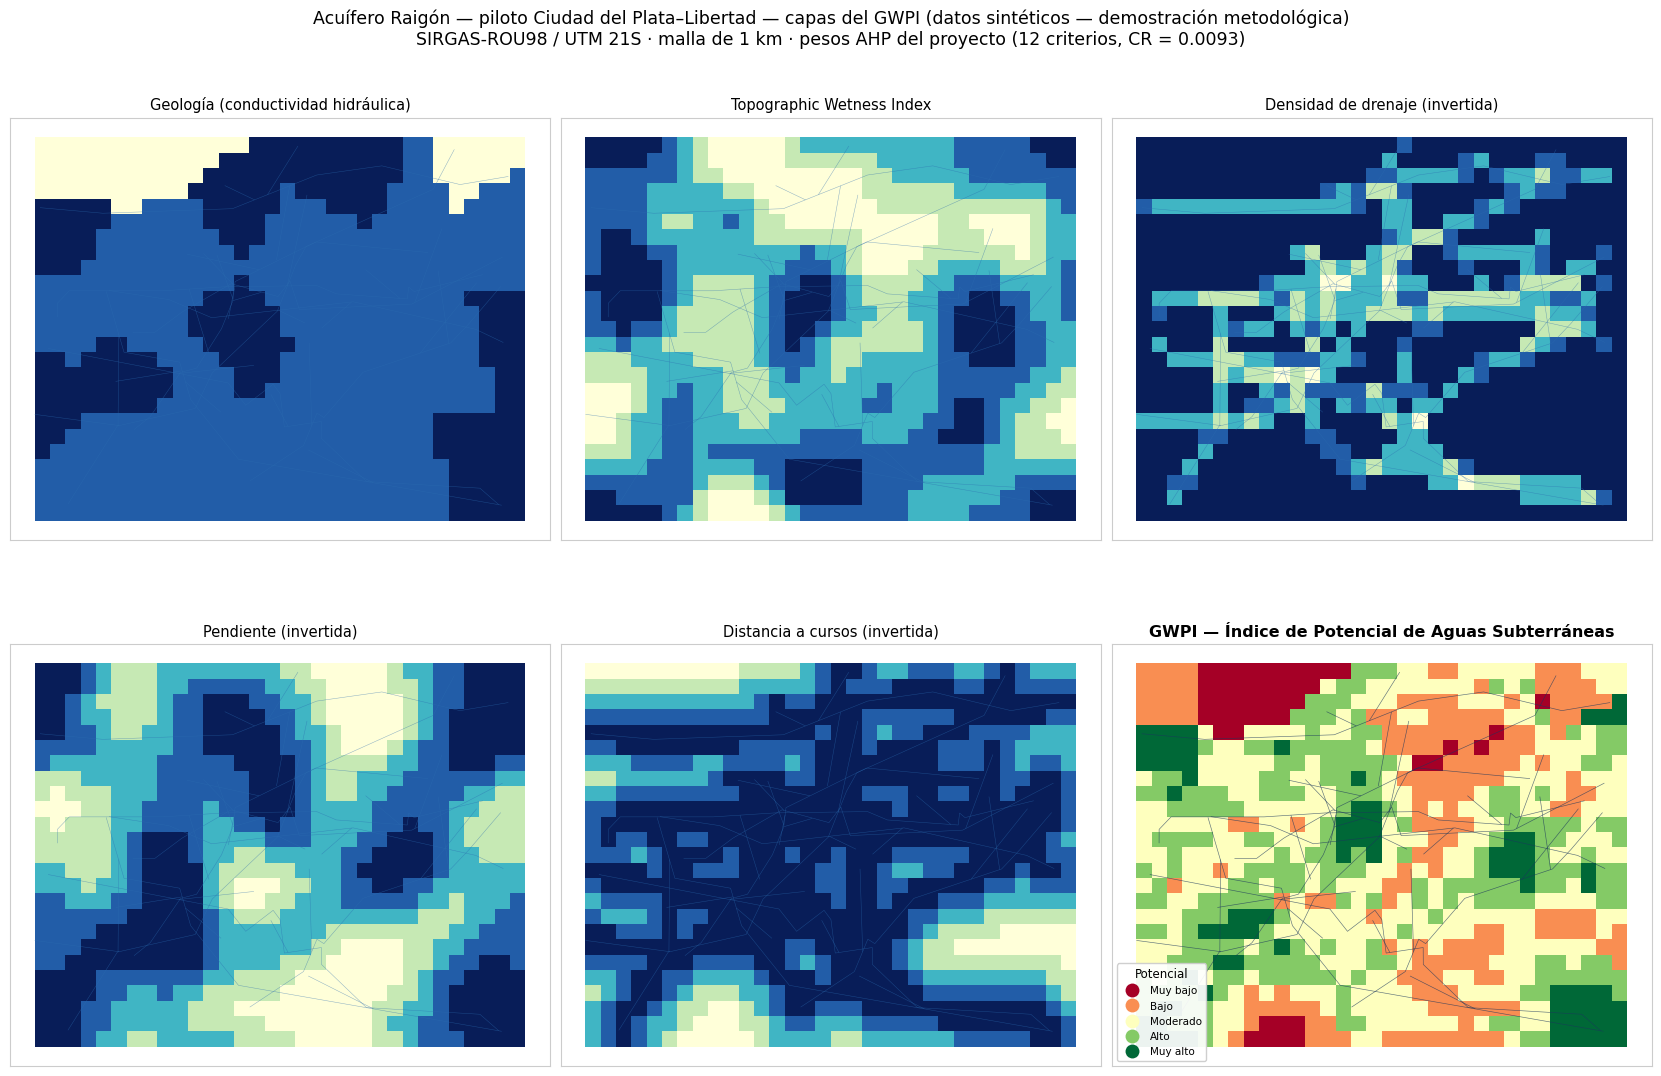

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 10.5), constrained_layout=True)

paneles = [
    ("r_geologia",      "Geología (conductividad hidráulica)", "YlGnBu"),
    ("r_twi",           "Topographic Wetness Index",           "YlGnBu"),
    ("r_dens_drenaje",  "Densidad de drenaje (invertida)",     "YlGnBu"),
    ("r_pendiente_pct", "Pendiente (invertida)",               "YlGnBu"),
    ("r_dist_cursos_m", "Distancia a cursos (invertida)",      "YlGnBu"),
]

for ax, (col, titulo, cmap) in zip(axes.ravel(), paneles):
    malla.plot(column=col, cmap=cmap, ax=ax, vmin=1, vmax=5,
               edgecolor="none", legend=False)
    drenaje.plot(ax=ax, color="#2b6cb0", linewidth=0.35, alpha=0.55)
    ax.set_title(titulo, fontsize=10.5, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_edgecolor("#cccccc")

ax = axes.ravel()[5]
malla.plot(column="clase_txt", cmap="RdYlGn", ax=ax, legend=True,
           edgecolor="none", legend_kwds={"loc": "lower left", "fontsize": 7.5,
                                          "framealpha": 0.93,
                                          "title": "Potencial", "title_fontsize": 8.5,
                                          "frameon": True})
drenaje.plot(ax=ax, color="#1a365d", linewidth=0.45, alpha=0.7)
ax.set_title("GWPI — Índice de Potencial de Aguas Subterráneas", fontsize=11.5,
             fontweight="bold", pad=6)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_edgecolor("#cccccc")

sub = "datos sintéticos — demostración metodológica" if SINTETICO else "capas del proyecto"
fig.suptitle(f"Acuífero Raigón — piloto Ciudad del Plata–Libertad — capas del GWPI ({sub})\n"
             f"SIRGAS-ROU98 / UTM 21S · malla de {CELDA_M/1000:g} km · "
             f"pesos AHP del proyecto (12 criterios, CR = 0.0093)",
             fontsize=12.5, y=1.055)

fig.savefig(DIR_SALIDA / "gwpi_paneles.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 13. Exportación

Se escriben tres productos: un **GeoPackage** con la malla calificada y las capas de entrada (un solo
archivo, varias capas, sin el límite de 10 caracteres del nombre de campo del shapefile), un **GeoTIFF**
del GWPI rasterizado a 30 m, y un **JSON** con los parámetros de la corrida para poder rehacerla igual.

In [19]:
gpkg = DIR_SALIDA / "gwpi_raigon.gpkg"
malla.to_file(gpkg, layer="malla_gwpi", driver="GPKG")
geologia.to_file(gpkg, layer="geologia", driver="GPKG")
drenaje.to_file(gpkg, layer="drenaje", driver="GPKG")
aoi.to_file(gpkg, layer="area_estudio", driver="GPKG")
if pozos is not None:
    pozos.to_file(gpkg, layer="pozos", driver="GPKG")

print(f"GeoPackage → {gpkg}")
for capa in gpd.list_layers(gpkg).itertuples():
    print(f"   · {capa.name:15s} {capa.geometry_type}")

GeoPackage → salidas/gwpi_raigon.gpkg
   · malla_gwpi      Polygon
   · geologia        MultiPolygon
   · drenaje         LineString
   · area_estudio    Polygon
   · pozos           Point


In [20]:
# GWPI rasterizado a la resolución de trabajo
gwpi_ras = rasterize(
    ((g, v) for g, v in zip(malla.geometry, malla["gwpi_norm"])),
    out_shape=(alto, ancho), transform=transform, fill=-9999.0, dtype="float32",
)
perfil = dict(driver="GTiff", height=alto, width=ancho, count=1, dtype="float32",
              crs=CRS_PRJ, transform=transform, nodata=-9999.0,
              compress="deflate", tiled=True, blockxsize=256, blockysize=256)

tif = DIR_SALIDA / "gwpi_raigon.tif"
with rasterio.open(tif, "w", **perfil) as dst:
    dst.write(gwpi_ras, 1)
    dst.set_band_description(1, "GWPI normalizado 0-100")

with rasterio.open(tif) as src:
    v = src.read(1, masked=True)
    print(f"GeoTIFF → {tif}")
    print(f"   {src.width} × {src.height} px · {src.crs} · {src.res[0]:.0f} m")
    print(f"   GWPI {v.min():.1f} – {v.max():.1f}  (media {v.mean():.1f})")

GeoTIFF → salidas/gwpi_raigon.tif
   1041 × 816 px · EPSG:5382 · 30 m
   GWPI 0.0 – 100.0  (media 57.0)


In [21]:
metadatos = {
    "proyecto": "GWPI — Acuífero Raigón, piloto Ciudad del Plata–Libertad, San José",
    "autor": "Juan Nahuel Lamas — GIEx, UTEC",
    "datos": "sintéticos reproducibles" if SINTETICO else "capas del proyecto",
    "semilla": SEMILLA if SINTETICO else None,
    "crs_trabajo": CRS_PRJ,
    "celda_m": CELDA_M,
    "resolucion_raster_m": RES_M,
    "n_celdas": int(len(malla)),
    "criterios": ETIQUETAS,
    "pesos_ahp": {e: round(float(p), 4) for e, p in zip(ETIQUETAS, w)},
    "lambda_max": round(float(lam), 4),
    "razon_consistencia": round(float(CR), 4),
    "rating_geologia": RATING_GEOLOGIA,
    "cortes_jenks": {k: [round(float(b), 4) for b in v] for k, v in cortes.items()},
    "versiones": {"geopandas": gpd.__version__, "rasterio": rasterio.__version__,
                  "mapclassify": mapclassify.__version__, "numpy": np.__version__,
                  "pandas": pd.__version__},
}
ruta_meta = DIR_SALIDA / "parametros_corrida.json"
ruta_meta.write_text(json.dumps(metadatos, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Parámetros → {ruta_meta}\n")
print(json.dumps(metadatos["pesos_ahp"], indent=2, ensure_ascii=False))

Parámetros → salidas/parametros_corrida.json

{
  "Geología": 0.2865,
  "TWI": 0.2242,
  "Pendiente": 0.1957,
  "Densidad drenaje": 0.1584,
  "Distancia a cursos": 0.1352
}


---

## Notas metodológicas y limitaciones

**Sobre la malla.** Una celda de 1 km es un compromiso entre la escala de la cartografía geológica de
entrada (1:100.000) y la resolución del modelo digital de elevación. Afinarla no aporta información: sólo
interpola con más detalle un dato que no lo tiene. El campo `frac_dominante` deja explícitas las celdas
donde la asignación geológica es ambigua, y son las primeras candidatas a revisión en campo.

**Sobre los pesos.** El AHP traslada al resultado el juicio de quien arma la matriz. La razón de
consistencia detecta contradicciones internas, pero no detecta un juicio consistentemente equivocado. Por
eso el paso 11 —el contraste con caudales medidos— no es opcional: es lo único que somete el modelo a un
dato externo.

**Sobre las variables climáticas.** En el proyecto completo, precipitación, evapotranspiración y temperatura
reciben un valor único para toda el área comparado contra el promedio nacional. Es una decisión propia, sin
precedente directo en la bibliografía de AHP-GWP revisada, y está documentada como tal en el README de la
carpeta. La alternativa —interpolar tres estaciones sobre 2.000 km²— habría introducido una estructura
espacial que el dato no respalda.

**Reproducibilidad.** El notebook corre de punta a punta sin datos externos. Con la semilla fija, dos
corridas dan resultados idénticos. Todos los parámetros de la corrida quedan en
`salidas/parametros_corrida.json`.

## Cómo correrlo

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
jupyter lab 01_preparacion_vectorial_gwpi.ipynb
```

Para usar las capas reales, colocar en `datos/` los archivos `drenaje.gpkg`, `geologia.gpkg`,
`pozos.gpkg`, `pendiente.tif` y `twi.tif`. El notebook los detecta solo.